--- Iniciando Simulação Paramétrica ---

--- Tabela de Resultados ---
 T2 [°C]  v2 [m^3/kg]  W_12 [kJ]  Q_12 [kJ]
     203      0.00002       0.00     548.04
     250      0.00002       0.01     911.37
     300      0.00002       0.01    1298.10
     400      0.00002       0.02    2085.70
     500      0.00003       0.02    2900.63


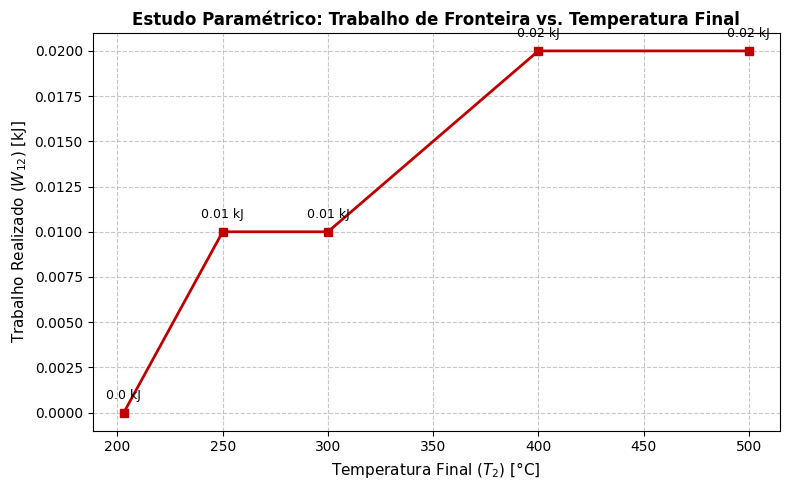

In [ ]:
import CoolProp.CoolProp as CP
import matplotlib.pyplot as plt
import pandas as pd
##Para que a simulação rode, favor instalar CoolProp usando "pip install CoolProp"
# =========================================================================
# EXERCÍCIO 01 - CENGEL 4-8 (PARAMETRIZADO)
# ASSUNTO: Trabalho de fronteira em fluido real (água)
# =========================================================================

print("--- Iniciando Simulação Paramétrica ---")

# --- DADOS DE ENTRADA ---
m = 4.95         # Massa total [kg]
P_kPa = 312      # Pressão de operação [kPa]
P_Pa = P_kPa * 1000  # Pressão [Pa] (O CoolProp trabalha com Pascal no SI)
x_1 = 1.0        # Título inicial (Vapor saturado seco)

# --- ESTADO 1: VAPOR SATURADO ---
# Obtendo volume específico inicial (V) e energia interna (U)
v_1 = CP.PropsSI('V', 'P', P_Pa, 'Q', x_1, 'Water')
u_1 = CP.PropsSI('U', 'P', P_Pa, 'Q', x_1, 'Water') / 1000  # Convertendo J/kg para kJ/kg

# --- ESTUDO PARAMÉTRICO ---
# Temperaturas finais desejadas para o estudo [°C]
temperaturas_C = [203, 250, 300, 400, 500]
resultados = []

for T2_C in temperaturas_C:
    T2_K = T2_C + 273.15  # O CoolProp exige temperatura em Kelvin

    # Estado 2: Vapor Superaquecido
    v_2 = CP.PropsSI('V', 'P', P_Pa, 'T', T2_K, 'Water')
    u_2 = CP.PropsSI('U', 'P', P_Pa, 'T', T2_K, 'Water') / 1000 # kJ/kg

    # Cálculo do Trabalho de Fronteira (W = P * dV)
    # Pressão em Pa * Volume em m^3 = Joules. Dividimos por 1000 para kJ.
    W_12 = m * P_Pa * (v_2 - v_1) / 1000

    # Cálculo da 1ª Lei (Calor Q)
    Q_12 = m * (u_2 - u_1) + W_12

    # Armazenando os dados na lista
    resultados.append({
        'T2 [°C]': T2_C,
        'v2 [m^3/kg]': round(v_2, 5),
        'W_12 [kJ]': round(W_12, 2),
        'Q_12 [kJ]': round(Q_12, 2)
    })

# --- EXIBIÇÃO DA TABELA ---
# Utilizando o Pandas para gerar uma tabela formatada no terminal
df = pd.DataFrame(resultados)
print("\n--- Tabela de Resultados ---")
print(df.to_string(index=False))

# --- GERAÇÃO DO GRÁFICO ---
plt.figure(figsize=(8, 5))
plt.plot(df['T2 [°C]'], df['W_12 [kJ]'], marker='s', linestyle='-', color='#c00000', linewidth=2)

# Formatação do gráfico
plt.title('Estudo Paramétrico: Trabalho de Fronteira vs. Temperatura Final', fontsize=12, fontweight='bold')
plt.xlabel('Temperatura Final ($T_2$) [°C]', fontsize=11)
plt.ylabel('Trabalho Realizado ($W_{12}$) [kJ]', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.7)

# Adicionando rótulos de dados nos pontos do gráfico
for i, txt in enumerate(df['W_12 [kJ]']):
    plt.annotate(f"{txt} kJ", (df['T2 [°C]'][i], df['W_12 [kJ]'][i]),
                 textcoords="offset points", xytext=(0,10), ha='center', fontsize=9)

# Exibe o gráfico na tela
plt.tight_layout()

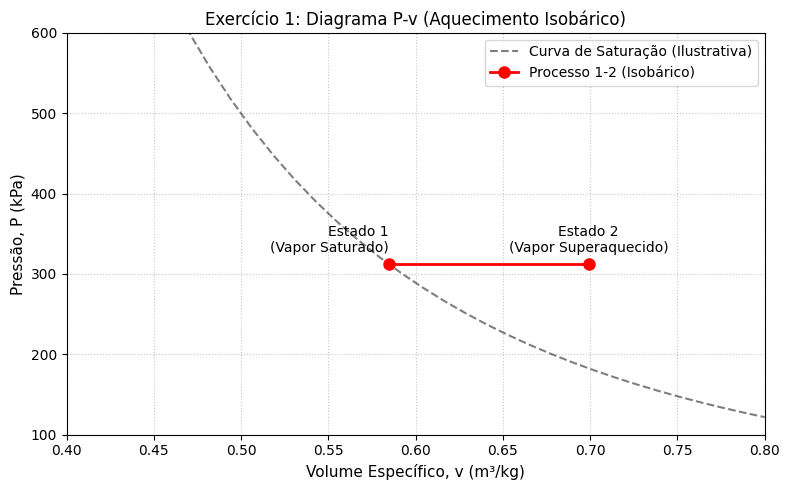

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Dados do Exercício 1
P_ex1 = [312, 312]
v_ex1 = [0.58479, 0.69910]

plt.figure(figsize=(8, 5))

# Criando uma linha curva genérica para representar o lado direito da campânula (vapor)
v_sat = np.linspace(0.2, 0.8, 50)
p_sat = 312 * (0.58479 / v_sat)**3  # Curva visual ilustrativa passando pelo ponto 1
plt.plot(v_sat, p_sat, 'k--', alpha=0.5, label='Curva de Saturação (Ilustrativa)')

# Plotando o processo
plt.plot(v_ex1, P_ex1, color='red', marker='o', linewidth=2, markersize=8, label='Processo 1-2 (Isobárico)')

# Anotações
plt.text(v_ex1[0], P_ex1[0] + 15, 'Estado 1\n(Vapor Saturado)', ha='right')
plt.text(v_ex1[1], P_ex1[1] + 15, 'Estado 2\n(Vapor Superaquecido)', ha='center')

# Formatação
plt.title('Exercício 1: Diagrama P-v (Aquecimento Isobárico)', fontsize=12)
plt.xlabel('Volume Específico, v (m³/kg)', fontsize=11)
plt.ylabel('Pressão, P (kPa)', fontsize=11)
plt.xlim(0.4, 0.8)
plt.ylim(100, 600)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

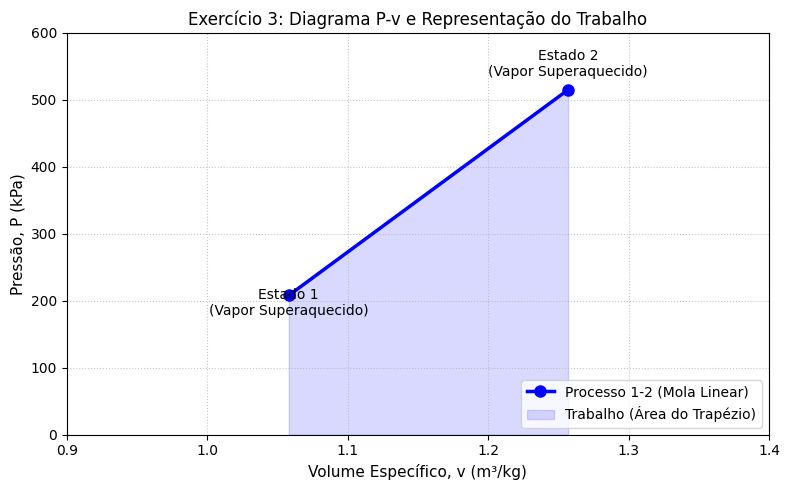

In [2]:
import matplotlib.pyplot as plt

# Dados do Exercício 3
P_ex3 = [208, 515]
v_ex3 = [1.05814, 1.25697]

plt.figure(figsize=(8, 5))

# Plotando a reta do processo
plt.plot(v_ex3, P_ex3, color='blue', marker='o', linewidth=2.5, markersize=8, label='Processo 1-2 (Mola Linear)')

# Preenchendo a área sob a curva (Trabalho)
plt.fill_between(v_ex3, P_ex3, color='blue', alpha=0.15, label='Trabalho (Área do Trapézio)')

# Anotações
plt.text(v_ex3[0], P_ex3[0] - 30, 'Estado 1\n(Vapor Superaquecido)', ha='center')
plt.text(v_ex3[1], P_ex3[1] + 20, 'Estado 2\n(Vapor Superaquecido)', ha='center')

# Formatação
plt.title('Exercício 3: Diagrama P-v e Representação do Trabalho', fontsize=12)
plt.xlabel('Volume Específico, v (m³/kg)', fontsize=11)
plt.ylabel('Pressão, P (kPa)', fontsize=11)
plt.xlim(0.9, 1.4)
plt.ylim(0, 600)
plt.legend(loc='lower right')
plt.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

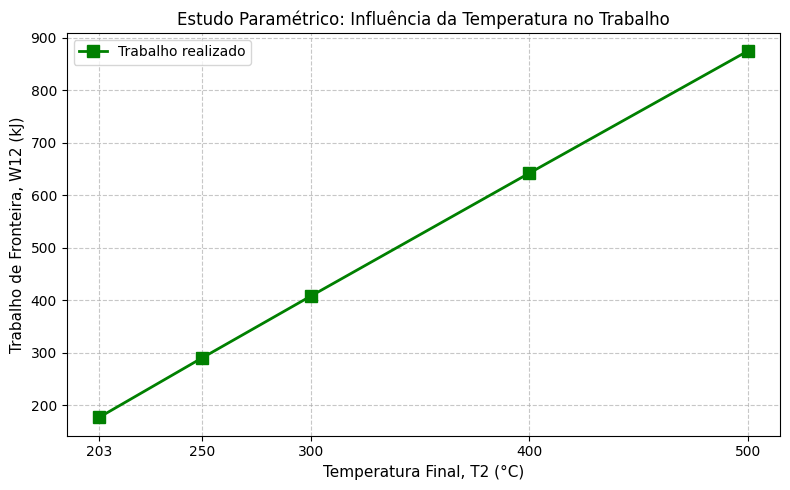

In [3]:
import matplotlib.pyplot as plt

# Dados da sua Tabela do Estudo Paramétrico
T2 = [203, 250, 300, 400, 500]
W12 = [176.54, 289.45, 407.80, 641.93, 874.51]

plt.figure(figsize=(8, 5))

# Plotando a correlação
plt.plot(T2, W12, color='green', marker='s', linewidth=2, markersize=8, label='Trabalho realizado')

# Formatação
plt.title('Estudo Paramétrico: Influência da Temperatura no Trabalho', fontsize=12)
plt.xlabel('Temperatura Final, T2 (°C)', fontsize=11)
plt.ylabel('Trabalho de Fronteira, W12 (kJ)', fontsize=11)
plt.xticks(T2) # Força os pontos exatos no eixo X
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [ ]:
pip install CoolProp

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.5/6.5 MB 54.8 MB/s eta 0:00:00
